In [1]:
from plotting import *

import numpy as np
import json

2026-06-02 17:42:59.082792: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

In [3]:
paths = {}

modeldir = "/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/"

paths['Transformer120e_2bit'] = modeldir + 'model-923bc2f5-Transformer120e_2bit-checkpoints/residuals.parquet'
paths['Transformer80e_2bit'] = modeldir + 'model-1fd6dcbc-Transformer80e_2bit-checkpoints/residuals.parquet'
paths['Transformer40e_2bit'] = modeldir + 'model-baa2aecf-Transformer40e_2bit-checkpoints/residuals.parquet'
paths['Transformer0e_2bit'] = modeldir + 'model-31ac8cc6-Transformer0e_2bit-checkpoints/residuals.parquet'

paths['MaxConv2D_HQ_0e_2bit'] = modeldir + 'model-5fa297bb-MaxConv2D_HQ_0e_2bit-checkpoints/residuals.parquet'
#paths['MaxConv2D_HQ_40e_2bit'] = modeldir + 'model-XXX-MaxConv2D_HQ_40e_2bit-checkpoints/residuals.parquet'
paths['MaxConv2D_HQ_80e_2bit'] = modeldir + 'model-5e6a173a-MaxConv2D_HQ_80e_2bit-checkpoints/residuals.parquet'
paths['MaxConv2D_HQ_120e_2bit'] = modeldir + 'model-c61695fd-MaxConv2D_HQ_120e_2bit-checkpoints/residuals.parquet'

paths['MaxConv2D_SQ_0e_2bit'] = modeldir + 'model-60350e7e-MaxConv2D_SQ_0e_2bit-checkpoints/residuals.parquet'
#paths['MaxConv2D_SQ_40e_2bit'] = modeldir + 'model-XXX-MaxConv2D_SQ_40e_2bit-checkpoints/residuals.parquet'
paths['MaxConv2D_SQ_80e_2bit'] = modeldir + 'model-58301193-MaxConv2D_SQ_80e_2bit-checkpoints/residuals.parquet'
#paths['MaxConv2D_SQ_120e_2bit'] = modeldir + 'model-XXX-MaxConv2D_SQ_120e_2bit-checkpoints/residuals.parquet'

#paths['Transformer120e_3bit'] = modeldir + 'model-c95f57a7-Transformer120e_3bit-checkpoints/residuals.parquet'
#paths['Transformer80e_3bit'] = modeldir + 'model-69c59d64-Transformer80e_3bit-checkpoints/residuals.parquet'
#paths['Transformer40e_3bit'] = modeldir + 'model-9289b6a2-Transformer40e_3bit-checkpoints/residuals.parquet'
#paths['Transformer0e_3bit'] = modeldir + 'model-a05f2088-Transformer0e_3bit-checkpoints/residuals.parquet'

#paths['Transformer120e_full'] = modeldir + 'model-80e62895-Transformer120e_full-checkpoints/residuals.parquet'
#paths['Transformer80e_full'] = modeldir + 'model-cbeb0147-Transformer80e_full-checkpoints/residuals.parquet'
#paths['Transformer40e_full'] = modeldir + 'model-e117d30d-Transformer40e_full-checkpoints/residuals.parquet'
#paths['Transformer0e_full'] = modeldir + 'model-7de53cb2-Transformer0e_full-checkpoints/residuals.parquet'

#paths['Transformer80e_MF3x3_full'] = modeldir + 'model-6a49b2f9-Transformer80e_full-checkpoints/residuals.parquet'

In [4]:
residuals = {}
df = {}

In [5]:
for m, path in paths.items():

    predictions = pd.read_parquet(path)
    df[m] = predictions
    residuals[m] = {}

    if len(predictions.columns) == 0:
        continue
                
    # Residuals for cotA 
    residuals[m]['mean_cotA'] = float(np.mean(predictions['residualcotA']))
    residuals[m]['std_cotA'] = float(np.std(predictions['residualcotA']))
    interval68_cotA = shortest_interval_68(predictions['residualcotA'], center_type='mean')
    residuals[m]['up68_cotA'] = interval68_cotA['error_high']
    residuals[m]['down68_cotA'] = interval68_cotA['error_low']

    # residuals for A
    residuals[m]['mean_A'] = float(np.mean(predictions['residualA']))
    residuals[m]['std_A'] = float(np.std(predictions['residualA']))
    interval68_A = shortest_interval_68(predictions['residualA'], center_type='mean')
    residuals[m]['up68_A'] = interval68_A['error_high']
    residuals[m]['down68_A'] = interval68_A['error_low']

    # Mean predicted uncertainty 
    residuals[m]['mean_upsigmax'] = float(np.mean(predictions['sigmax']))
    residuals[m]['mean_downsigmax'] = float(np.mean(predictions['sigmax']))
    residuals[m]['mean_upsigmay'] = float(np.mean(predictions['sigmay']))
    residuals[m]['mean_downsigmay'] = float(np.mean(predictions['sigmay']))
    residuals[m]['mean_upsigmacotA'] = float(np.mean(predictions['sigmacotA']))
    residuals[m]['mean_downsigmacotA'] = float(np.mean(predictions['sigmacotA']))
    residuals[m]['mean_upsigmaA'] = float(np.mean(abs(inverse_cot(predictions['cotA'] + predictions['sigmacotA'])*180/np.pi - predictions['A'])))
    residuals[m]['mean_downsigmaA'] = float(np.mean(abs(inverse_cot(predictions['cotA'] - predictions['sigmacotA'])*180/np.pi - predictions['A'])))            
    residuals[m]['mean_upsigmacotB'] = float(np.mean(predictions['sigmacotB']))
    residuals[m]['mean_downsigmacotB'] = float(np.mean(predictions['sigmacotB']))
    residuals[m]['mean_upsigmaB'] = float(np.mean(abs(inverse_cot(predictions['cotB'] + predictions['sigmacotB'])*180/np.pi - predictions['B'])))
    residuals[m]['mean_downsigmaB'] = float(np.mean(abs(inverse_cot(predictions['cotB'] - predictions['sigmacotB'])*180/np.pi - predictions['B'])))

    # Residuals for x and y (microns)
    for v in ['x','y']:
        # Mean
        residuals[m]['mean_'+v] = float(np.mean(predictions['residual'+v]))
        # Std -- replace with smallest window containing 68%
        residuals[m]['std_'+v] = float(np.std(predictions['residual'+v]))

        interval68 = shortest_interval_68(predictions['residual'+v], center_type='mean')
        residuals[m]['up68_'+v] = interval68['error_high']
        residuals[m]['down68_'+v] = interval68['error_low']

    # Residuals for cotB
    residuals[m]['mean_cotB'] = float(np.mean(predictions['residualcotB']))
    residuals[m]['std_cotB'] = float(np.std(predictions['residualcotB']))
    interval68_cotB = shortest_interval_68(predictions['residualcotB'], center_type='mean')
    residuals[m]['up68_cotB'] = interval68_cotB['error_high']
    residuals[m]['down68_cotB'] = interval68_cotB['error_low']

    # Residuals for B
    residuals[m]['mean_B'] = float(np.mean(predictions['residualB']))
    residuals[m]['std_B'] = float(np.std(predictions['residualB']))
    interval68_B = shortest_interval_68(predictions['residualB'], center_type='mean')
    residuals[m]['up68_B'] = interval68_B['error_high']
    residuals[m]['down68_B'] = interval68_B['error_low']
    

In [6]:
with open('residuals.json', 'w') as fp:
    json.dump(residuals, fp)

In [7]:
def draw(names):
    fig, ax = plt.subplots(2,4,figsize=(10,4),sharey='row', constrained_layout=True, gridspec_kw={'height_ratios': [1, 2]})

    ax[0,0].axis('off')
    ax[0,1].axis('off')
    ax[0,2].axis('off')
    ax[0,3].axis('off')
    
    legend_entries = []
    legend_entries2 = []

    #names = ['Transformer0e_2bit','MaxConv2D_HQ_0e_2bit','MaxConv2D_SQ_0e_2bit']
    
    for i,m in enumerate(names):

        print(m)

        # x
        ax[1,0].set_xlabel(r'$R_x$ [um]')
        h1 = ax[1,0].hist(df[m]["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i],label=m)
        legend_entries += h1[-1]
        ax[1,0].set_yscale('log')
    
        # y
        ax[1,1].set_xlabel(r'$R_y$ [um]')
        ax[1,1].hist(df[m]["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])
    
        # alpha
        ax[1,2].set_xlabel(r'$R_\alpha$ [deg]')
        ax[1,2].hist(df[m]["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
        
        # beta
        ax[1,3].set_xlabel(r'$R_\beta$ [deg]')
        ax[1,3].hist(df[m]["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    gs = ax[0, 2].get_gridspec()
    ax[0,0].remove()
    ax[0,1].remove()
    axbig = fig.add_subplot(gs[0, 0:2])
    axbig.axis('off')
    axbig.legend(legend_entries, names, frameon=False,loc='center left',fontsize=fontsize)
    plt.tight_layout()

In [8]:
# 0e NOISE, COMPARE PRECISION
#draw(['Transformer0e_2bit','Transformer0e_3bit','Transformer0e_full'])

Transformer0e_2bit
Transformer40e_2bit
Transformer80e_2bit
Transformer120e_2bit


/tmp/ipykernel_501904/3417293456.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


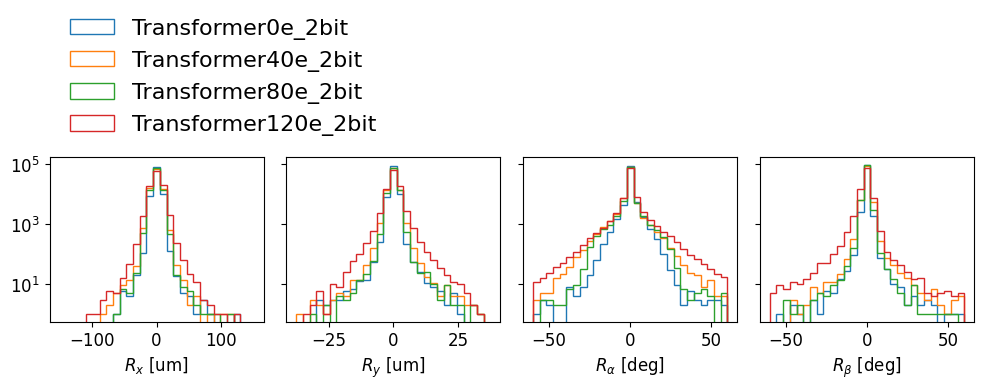

In [9]:
# 2 BIT TRANSFORMER, COMPARE NOISE
draw(['Transformer0e_2bit','Transformer40e_2bit','Transformer80e_2bit','Transformer120e_2bit'])

In [10]:
# 3 BIT TRANSFORMER, COMPARE NOISE
#draw(['Transformer0e_3bit','Transformer40e_3bit','Transformer80e_3bit','Transformer120e_3bit'])

In [11]:
# FULL PRECISION TRANSFORMER, COMPARE NOISE
#draw(['Transformer0e_full','Transformer40e_full','Transformer80e_full','Transformer120e_full'])

In [12]:
# 80e NOISE, COMPARE MEAN FILTER
#draw(['Transformer80e_full','Transformer80e_MF3x3_full'])

Transformer0e_2bit
MaxConv2D_HQ_0e_2bit
MaxConv2D_SQ_0e_2bit


/tmp/ipykernel_501904/3417293456.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


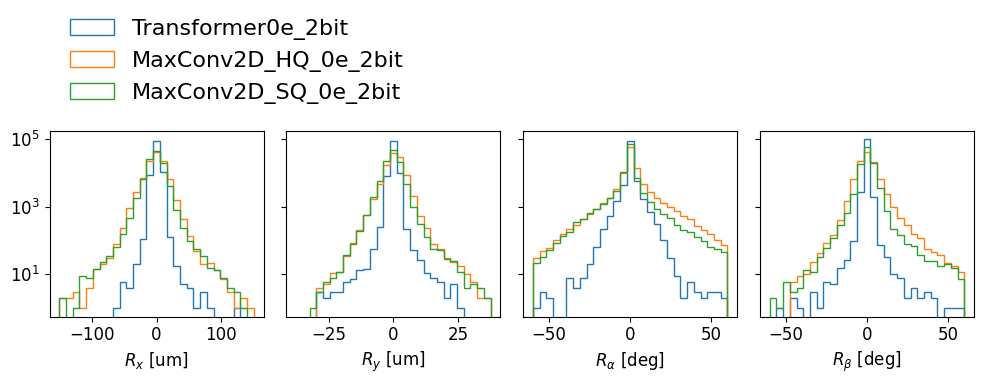

In [13]:
# 2 BIT 0e, COMPARE TRANSFORMER AND MAXCONV2D
draw(['Transformer0e_2bit','MaxConv2D_HQ_0e_2bit','MaxConv2D_SQ_0e_2bit'])

Transformer80e_2bit
MaxConv2D_HQ_80e_2bit
MaxConv2D_SQ_80e_2bit


/tmp/ipykernel_501904/3417293456.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


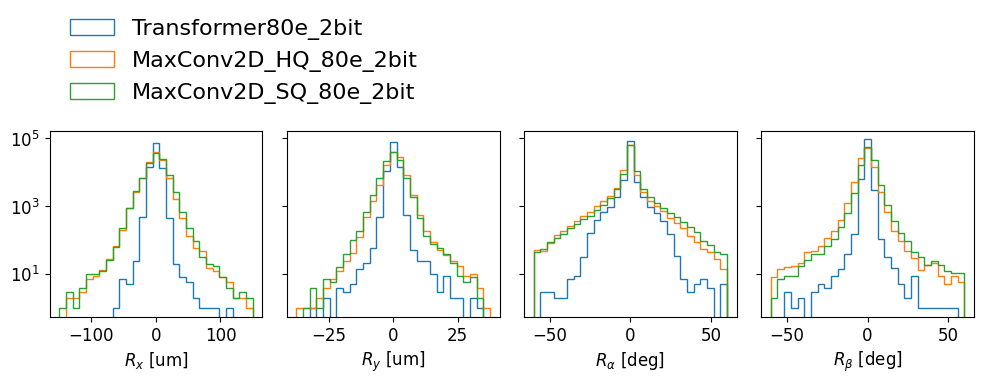

In [14]:
# 2 BIT 80e, COMPARE TRANSFORMER AND MAXCONV2D
draw(['Transformer80e_2bit','MaxConv2D_HQ_80e_2bit','MaxConv2D_SQ_80e_2bit'])

Transformer120e_2bit
MaxConv2D_HQ_120e_2bit
MaxConv2D_SQ_120e_2bit


KeyError: 'MaxConv2D_SQ_120e_2bit'

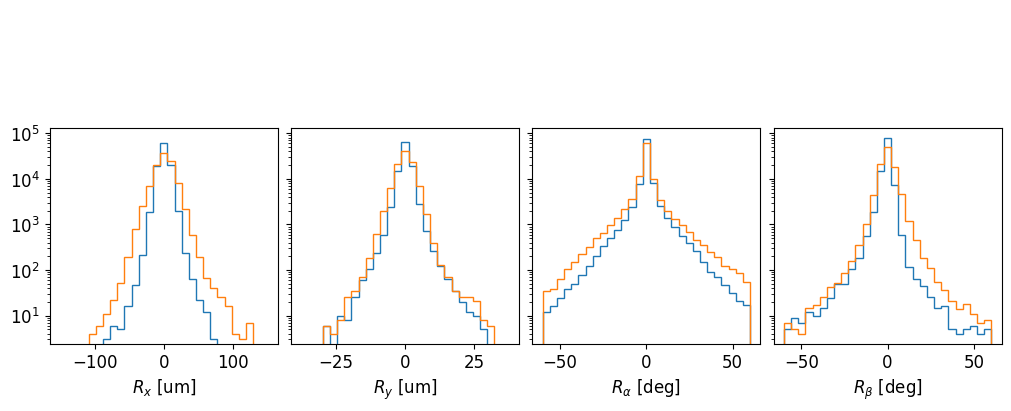

In [15]:
# 2 BIT 120e, COMPARE TRANSFORMER AND MAXCONV2D
draw(['Transformer120e_2bit','MaxConv2D_HQ_120e_2bit','MaxConv2D_SQ_120e_2bit'])